✅ Using file: materiae_All_Labelled_withSOC_with_Composition_Vectors.csv
Current working directory: /content
📄 Loading dataset: materiae_All_Labelled_withSOC_with_Composition_Vectors.csv
✅ Dataset loaded: 22245 samples, 118 features
📊 Split sizes: train=15571, val=4449, test=2225
Using device: cuda
Epoch 001/50 | Train Loss: 0.3519 | Val Loss: 0.2826 | Val Acc: 0.897 | Val AUC: 0.944
Epoch 002/50 | Train Loss: 0.2760 | Val Loss: 0.2669 | Val Acc: 0.903 | Val AUC: 0.950
Epoch 003/50 | Train Loss: 0.2663 | Val Loss: 0.2555 | Val Acc: 0.907 | Val AUC: 0.954
Epoch 004/50 | Train Loss: 0.2499 | Val Loss: 0.2522 | Val Acc: 0.911 | Val AUC: 0.955
Epoch 005/50 | Train Loss: 0.2395 | Val Loss: 0.2516 | Val Acc: 0.908 | Val AUC: 0.956
Epoch 006/50 | Train Loss: 0.2321 | Val Loss: 0.2502 | Val Acc: 0.912 | Val AUC: 0.958
Epoch 007/50 | Train Loss: 0.2248 | Val Loss: 0.2635 | Val Acc: 0.909 | Val AUC: 0.956
Epoch 008/50 | Train Loss: 0.2181 | Val Loss: 0.2509 | Val Acc: 0.910 | Val AUC: 0.957
Epoc

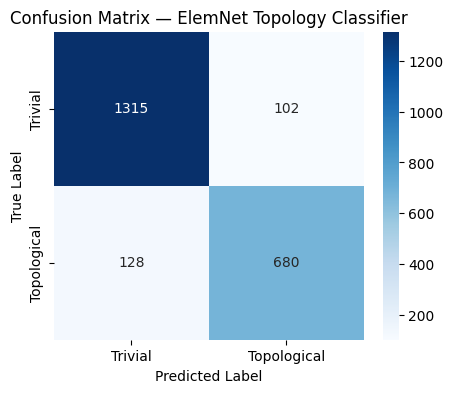

In [ ]:
# Preliminary ElemNet model (Early version with manually-chosen architecture, keep scrolling for the final model)
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split

csv_file = "materiae_All_Labelled_withSOC_with_Composition_Vectors.csv"

if not os.path.exists(csv_file):
    raise FileNotFoundError(f"❌ Could not find {csv_file} in current directory: {os.getcwd()}")

print("✅ Using file:", csv_file)
print("Current working directory:", os.getcwd())

print(f"📄 Loading dataset: {csv_file}")
df = pd.read_csv(csv_file, on_bad_lines="skip", engine="python")

if "composition_vector" not in df.columns:
    raise ValueError("❌ 'composition_vector' column missing from file.")

df["composition_vector"] = df["composition_vector"].apply(eval)
X = np.vstack(df["composition_vector"].values).astype(np.float32)
y = df["is_topological"].astype(np.float32).values

print(f"✅ Dataset loaded: {len(y)} samples, {X.shape[1]} features")

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=1/3, stratify=y_temp, random_state=42
)

print(f"📊 Split sizes: train={len(y_train)}, val={len(y_val)}, test={len(y_test)}")

train_dataset = TensorDataset(torch.tensor(X_train), torch.tensor(y_train))
val_dataset = TensorDataset(torch.tensor(X_val), torch.tensor(y_val))
test_dataset = TensorDataset(torch.tensor(X_test), torch.tensor(y_test))

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

#  ElemNet model (Early version with manually-chosen architecture, keep scrolling for the final model)

class ElemNet(nn.Module):
    def __init__(self, input_dim=118, hidden_dims=[1024, 512, 256, 128], dropout=0.3):
        super().__init__()
        layers = []
        dims = [input_dim] + hidden_dims
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i + 1]))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
        layers.append(nn.Linear(hidden_dims[-1], 1))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return torch.sigmoid(self.network(x)).squeeze(1)



# Training and evaluation

def train_model(model, train_loader, val_loader, device, epochs=50, lr=1e-3):
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    best_val_loss = np.inf
    best_state = None
    patience, patience_counter = 5, 0

    for epoch in range(epochs):
        model.train()
        train_losses = []
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            y_pred = model(X)
            loss = criterion(y_pred, y)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        # Validation
        model.eval()
        all_y, all_preds = [], []
        with torch.no_grad():
            for X, y in val_loader:
                X, y = X.to(device), y.to(device)
                preds = model(X)
                all_y.extend(y.cpu().numpy())
                all_preds.extend(preds.cpu().numpy())

        val_loss = criterion(torch.tensor(all_preds), torch.tensor(all_y)).item()
        val_acc = accuracy_score(all_y, np.array(all_preds) > 0.5)
        try:
            val_auc = roc_auc_score(all_y, all_preds)
        except:
            val_auc = float("nan")

        print(f"Epoch {epoch+1:03d}/{epochs} | "
              f"Train Loss: {np.mean(train_losses):.4f} | "
              f"Val Loss: {val_loss:.4f} | "
              f"Val Acc: {val_acc:.3f} | Val AUC: {val_auc:.3f}")

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = model.state_dict()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("🛑 Early stopping triggered.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model

# evlauation and metrics

from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    model = ElemNet().to(device)
    trained_model = train_model(model, train_loader, val_loader, device,
                                epochs=50, lr=1e-3)

    torch.save(trained_model.state_dict(), "elemnet_topology_classifier.pt")
    print("✅ Model saved as elemnet_topology_classifier.pt")

    model.eval()
    all_y, all_preds = [], []
    with torch.no_grad():
        for X, y in test_loader:
            X, y = X.to(device), y.to(device)
            preds = model(X)
            all_y.extend(y.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    pred_labels = (np.array(all_preds) > 0.5).astype(int)
    acc = accuracy_score(all_y, pred_labels)
    auc = roc_auc_score(all_y, all_preds)
    prec = precision_score(all_y, pred_labels)
    rec = recall_score(all_y, pred_labels)
    f1 = f1_score(all_y, pred_labels)

    print("\n📊 ===== FINAL TEST METRICS =====")
    print(f"Accuracy : {acc:.4f}")
    print(f"AUC      : {auc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print("\nDetailed classification report:")
    print(classification_report(all_y, pred_labels, target_names=["Trivial", "Topological"]))

    cm = confusion_matrix(all_y, pred_labels)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Trivial", "Topological"], yticklabels=["Trivial", "Topological"])
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix — ElemNet Topology Classifier")
    plt.show()


In [ ]:
# Application of the above trained model to the discovery dataset.

import torch
import torch.nn as nn
import pandas as pd
import numpy as np

class ElemNet(nn.Module):
    def __init__(self, input_dim=118, hidden_dims=[1024, 512, 256, 128], dropout=0.3):
        super().__init__()
        layers = []
        dims = [input_dim] + hidden_dims
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i+1]))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
        layers.append(nn.Linear(hidden_dims[-1], 1))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return torch.sigmoid(self.network(x)).squeeze(1)

# Load trained weights
model_path = "elemnet_topology_classifier.pt"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ElemNet().to(device)
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()
print(f"✅ Model loaded on {device}")

# Load discovery dataset (unlabeled materials)
csv_file = "materiae_filtered_by_spacegroups_Trivial_Insulators_Trivial_SI_withCompositionVectors.csv"
df = pd.read_csv(csv_file)
df["composition_vector"] = df["composition_vector"].apply(eval)
X_new = np.vstack(df["composition_vector"].values).astype(np.float32)
X_tensor = torch.tensor(X_new).to(device)

with torch.no_grad():
    preds = model(X_tensor).cpu().numpy()

df["predicted_topological_prob"] = preds
df["predicted_class"] = (df["predicted_topological_prob"] > 0.5).astype(int)

# ranking according to the probability of being topological
df_sorted = df.sort_values(by="predicted_topological_prob", ascending=False)

output_file = "predicted_topological_candidates.csv"
df_sorted.to_csv(output_file, index=False)

print(f"✅ Predictions saved → {output_file}")
print(df_sorted[["formula", "predicted_topological_prob"]].head(10))


✅ Model loaded on cuda
✅ Predictions saved → predicted_topological_candidates.csv
           formula  predicted_topological_prob
3058      Pr8Ga3Co                    0.999957
2972        LaAgGe                    0.999824
1943         LiRh3                    0.999746
1890  Sc5(Re2Si3)4                    0.999639
1784         TbSn3                    0.999511
55       Sc3Re2Si3                    0.999489
1109          TiSi                    0.999454
1971          TiSi                    0.999454
1891         DySn3                    0.999128
3118        Th7Ru3                    0.999102


In [ ]:
#Flexible ElemNet model to search for the best architecture with Optuna hyperparameter tuning (final model)


!pip install optuna --quiet
import optuna
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score

csv_file = "materiae_All_Labelled_withSOC_with_Composition_Vectors.csv"
df = pd.read_csv(csv_file, on_bad_lines="skip", engine="python")
df["composition_vector"] = df["composition_vector"].apply(eval)
X = np.vstack(df["composition_vector"].values).astype(np.float32)
y = df["is_topological"].astype(np.float32).values


X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

train_loader = DataLoader(TensorDataset(torch.tensor(X_train), torch.tensor(y_train)), batch_size=64, shuffle=True)
val_loader   = DataLoader(TensorDataset(torch.tensor(X_val),   torch.tensor(y_val)),   batch_size=64, shuffle=False)
test_loader  = DataLoader(TensorDataset(torch.tensor(X_test),  torch.tensor(y_test)),  batch_size=64, shuffle=False)

print(f"✅ Dataset split → train: {len(X_train)}, val: {len(X_val)}, test: {len(X_test)}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("🚀 Using device:", device)

# Define flexible ElemNet model

class DynamicElemNet(nn.Module):
    def __init__(self, input_dim=118, hidden_dims=None, dropout=0.3, act_fn=nn.ReLU):
        super().__init__()
        if hidden_dims is None:
            hidden_dims = [512, 256, 128]
        layers = []
        dims = [input_dim] + hidden_dims
        for i in range(len(dims)-1):
            layers.append(nn.Linear(dims[i], dims[i+1]))
            layers.append(nn.BatchNorm1d(dims[i+1]))
            layers.append(act_fn())
            layers.append(nn.Dropout(dropout))
        layers.append(nn.Linear(hidden_dims[-1], 1))
        self.network = nn.Sequential(*layers)
    def forward(self, x):
        return torch.sigmoid(self.network(x)).squeeze(1)


def objective(trial):
    n_layers = trial.suggest_int("n_layers", 3, 20)
    dropout = trial.suggest_float("dropout", 0.15, 0.4)
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    act_name = trial.suggest_categorical("activation", ["ReLU", "GELU", "LeakyReLU"])

   
    hidden_dims = []
    prev_size = 118
    for i in range(n_layers):
        # force monotonically decreasing or varying structure
        next_size = trial.suggest_categorical(f"layer_{i+1}_size", [128, 256, 512, 1024, 2048])
        hidden_dims.append(next_size)
        prev_size = next_size

    act_fn = getattr(nn, act_name)
    model = DynamicElemNet(input_dim=118, hidden_dims=hidden_dims, dropout=dropout, act_fn=act_fn).to(device)

    optimizer = optim.AdamW(model.parameters(), lr=lr)
    criterion = nn.BCELoss()

    for epoch in range(10):
        model.train()
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(Xb), yb)
            loss.backward()
            optimizer.step()

   
    model.eval()
    preds, true = [], []
    with torch.no_grad():
        for Xb, yb in val_loader:
            Xb = Xb.to(device)
            preds.extend(model(Xb).cpu().numpy())
            true.extend(yb.numpy())

    auc = roc_auc_score(true, preds) if len(set(true)) > 1 else 0.5
    print(f"Trial finished → layers={hidden_dims}, act={act_name}, AUC={auc:.4f}")
    return auc


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=25, timeout=3600)

print("✅ Best trial:")
print(study.best_trial.params)
print(f"Best Validation AUC: {study.best_value:.4f}")


[I 2025-11-04 05:49:40,740] A new study created in memory with name: no-name-bb0ad3e8-a253-43ab-a41e-e3207c86142f


✅ Dataset split → train: 15571, val: 3337, test: 3337
🚀 Using device: cuda


[I 2025-11-04 05:49:57,407] Trial 0 finished with value: 0.9564627086040586 and parameters: {'n_layers': 11, 'dropout': 0.1898836911587093, 'lr': 0.0035351825524181004, 'activation': 'LeakyReLU', 'layer_1_size': 512, 'layer_2_size': 512, 'layer_3_size': 256, 'layer_4_size': 2048, 'layer_5_size': 128, 'layer_6_size': 2048, 'layer_7_size': 128, 'layer_8_size': 2048, 'layer_9_size': 2048, 'layer_10_size': 256, 'layer_11_size': 512}. Best is trial 0 with value: 0.9564627086040586.


Trial finished → layers=[512, 512, 256, 2048, 128, 2048, 128, 2048, 2048, 256, 512], act=LeakyReLU, AUC=0.9565


[I 2025-11-04 05:50:12,780] Trial 1 finished with value: 0.9597754551678847 and parameters: {'n_layers': 10, 'dropout': 0.24438995226284593, 'lr': 0.007346293231237608, 'activation': 'LeakyReLU', 'layer_1_size': 2048, 'layer_2_size': 128, 'layer_3_size': 512, 'layer_4_size': 256, 'layer_5_size': 512, 'layer_6_size': 2048, 'layer_7_size': 128, 'layer_8_size': 256, 'layer_9_size': 512, 'layer_10_size': 1024}. Best is trial 1 with value: 0.9597754551678847.


...

Trial finished → layers=[2048, 128, 512, 256, 128, 128], act=LeakyReLU, AUC=0.9589


[I 2025-11-04 05:55:49,385] Trial 23 finished with value: 0.9575871405660275 and parameters: {'n_layers': 3, 'dropout': 0.20242041498171648, 'lr': 0.002829518213251935, 'activation': 'LeakyReLU', 'layer_1_size': 2048, 'layer_2_size': 128, 'layer_3_size': 512}. Best is trial 10 with value: 0.959964477731046.


Trial finished → layers=[2048, 128, 512], act=LeakyReLU, AUC=0.9576


[I 2025-11-04 05:56:03,611] Trial 24 finished with value: 0.9582190270810724 and parameters: {'n_layers': 9, 'dropout': 0.2711846638125903, 'lr': 0.0006878971508692097, 'activation': 'LeakyReLU', 'layer_1_size': 1024, 'layer_2_size': 128, 'layer_3_size': 512, 'layer_4_size': 256, 'layer_5_size': 128, 'layer_6_size': 256, 'layer_7_size': 1024, 'layer_8_size': 1024, 'layer_9_size': 512}. Best is trial 10 with value: 0.959964477731046.


Trial finished → layers=[1024, 128, 512, 256, 128, 256, 1024, 1024, 512], act=LeakyReLU, AUC=0.9582
✅ Best trial:
{'n_layers': 5, 'dropout': 0.2173497061241447, 'lr': 0.0015987187986284113, 'activation': 'LeakyReLU', 'layer_1_size': 2048, 'layer_2_size': 128, 'layer_3_size': 512, 'layer_4_size': 256, 'layer_5_size': 128}
Best Validation AUC: 0.9600


In [ ]:
# hyperparameters optimization over the best architecture from Optuna (final model)

from sklearn.model_selection import train_test_split
import numpy as np, torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import pandas as pd

csv_file = "materiae_All_Labelled_withSOC_with_Composition_Vectors.csv"
df = pd.read_csv(csv_file, on_bad_lines="skip", engine="python")
df["composition_vector"] = df["composition_vector"].apply(eval)
X = np.vstack(df["composition_vector"].values).astype(np.float32)
y = df["is_topological"].astype(np.float32).values

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)
X_val, X_test, y_val, y_test   = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

print(f"✅ Data split → Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class ElemNetBest(nn.Module):
    def __init__(self):
        super().__init__()
        hidden_dims = [2048, 128, 512, 256, 128]
        dropout = 0.217
        act_fn = nn.LeakyReLU
        layers, dims = [], [118] + hidden_dims
        for i in range(len(dims) - 1):
            layers += [nn.Linear(dims[i], dims[i+1]),
                       nn.BatchNorm1d(dims[i+1]),
                       act_fn(),
                       nn.Dropout(dropout)]
        layers.append(nn.Linear(hidden_dims[-1], 1))
        self.network = nn.Sequential(*layers)
    def forward(self, x): return torch.sigmoid(self.network(x)).squeeze(1)


def train_model(X_train, y_train, X_val, y_val, max_epochs=80, patience=7):
    train_loader = DataLoader(TensorDataset(torch.tensor(X_train), torch.tensor(y_train)), batch_size=64, shuffle=True)
    val_loader   = DataLoader(TensorDataset(torch.tensor(X_val), torch.tensor(y_val)), batch_size=64, shuffle=False)

    model = ElemNetBest().to(device)
    optimizer = optim.AdamW(model.parameters(), lr=0.0015987187986284113)
    criterion = nn.BCELoss()

    best_state, best_val_loss, patience_counter = None, np.inf, 0
    for epoch in range(1, max_epochs+1):
       
        model.train(); batch_losses=[]
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(Xb), yb); loss.backward(); optimizer.step()
            batch_losses.append(loss.item())
        train_loss = np.mean(batch_losses)

      
        model.eval(); preds,true,val_losses=[],[],[]
        with torch.no_grad():
            for Xb,yb in val_loader:
                Xb,yb=Xb.to(device),yb.to(device)
                out=model(Xb)
                val_losses.append(criterion(out,yb).item())
                preds.extend(out.cpu().numpy()); true.extend(yb.cpu().numpy())
        val_loss=np.mean(val_losses); val_auc=roc_auc_score(true,preds)
        print(f"Epoch {epoch:02d}/{max_epochs} | Train={train_loss:.4f} | Val={val_loss:.4f} | AUC={val_auc:.4f}")

        if val_loss<best_val_loss:
            best_val_loss,val_auc,best_state=val_loss,val_auc,model.state_dict(); patience_counter=0
        else:
            patience_counter+=1
            if patience_counter>=patience:
                print(f"🛑 Early stopping at epoch {epoch}")
                break

    model.load_state_dict(best_state)
    return model


print("\n🔧 Training on train+val (85%) and testing on hold-out test set...")
# First, combine train and val for final training
X_trainval = np.vstack([X_train, X_val])
y_trainval = np.concatenate([y_train, y_val])

model_final = train_model(X_trainval, y_trainval, X_val, y_val, max_epochs=150, patience=7)  # using val for early stop heuristic


test_loader = DataLoader(TensorDataset(torch.tensor(X_test), torch.tensor(y_test)), batch_size=64, shuffle=False)
model_final.eval(); preds,true=[],[]
with torch.no_grad():
    for Xb,yb in test_loader:
        Xb,yb=Xb.to(device),yb.to(device)
        preds.extend(model_final(Xb).cpu().numpy()); true.extend(yb.cpu().numpy())

preds, true = np.array(preds), np.array(true)
auc  = roc_auc_score(true,preds)
acc  = accuracy_score(true,preds>0.5)
prec = precision_score(true,preds>0.5)
rec  = recall_score(true,preds>0.5)
f1   = f1_score(true,preds>0.5)

print("\n📊 Final Test Metrics")
print(f"AUC={auc:.4f} | ACC={acc:.4f} | Precision={prec:.4f} | Recall={rec:.4f} | F1={f1:.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(true,preds>0.5))
print("\nClassification Report:\n", classification_report(true,preds>0.5,digits=3))

torch.save(model_final.state_dict(),"elemnet_final_trainval.pt")
print("\n✅ Model saved as elemnet_final_trainval.pt")


✅ Data split → Train: 15571, Val: 3337, Test: 3337

🔧 Training on train+val (85%) and testing on hold-out test set...
Epoch 01/150 | Train=0.3098 | Val=0.2543 | AUC=0.9547
Epoch 02/150 | Train=0.2695 | Val=0.2270 | AUC=0.9635
Epoch 03/150 | Train=0.2574 | Val=0.2263 | AUC=0.9651
Epoch 04/150 | Train=0.2491 | Val=0.2180 | AUC=0.9663
Epoch 05/150 | Train=0.2436 | Val=0.2113 | AUC=0.9677
Epoch 06/150 | Train=0.2405 | Val=0.2093 | AUC=0.9696
Epoch 07/150 | Train=0.2345 | Val=0.2006 | AUC=0.9715
Epoch 08/150 | Train=0.2307 | Val=0.1934 | AUC=0.9743
Epoch 09/150 | Train=0.2241 | Val=0.1897 | AUC=0.9757
Epoch 10/150 | Train=0.2190 | Val=0.1882 | AUC=0.9764
Epoch 11/150 | Train=0.2154 | Val=0.1808 | AUC=0.9786
Epoch 12/150 | Train=0.2110 | Val=0.1787 | AUC=0.9806
Epoch 13/150 | Train=0.2065 | Val=0.1750 | AUC=0.9809
Epoch 14/150 | Train=0.2037 | Val=0.1711 | AUC=0.9805
Epoch 15/150 | Train=0.1980 | Val=0.1766 | AUC=0.9790
Epoch 16/150 | Train=0.1952 | Val=0.1629 | AUC=0.9827
Epoch 17/150 | Tra

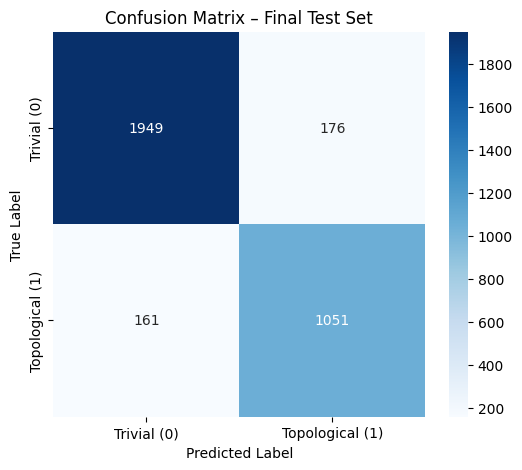

In [ ]:
# Evaluating the confusion matrix visualization of the final model performance over the final test set
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

y_pred_binary = (preds > 0.5).astype(int)

cm = confusion_matrix(true, y_pred_binary)
labels = ["Trivial (0)", "Topological (1)"]

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – Final Test Set")
plt.show()


✅ Predictions saved to: predicted_topological_candidates_from_trivial_set.csv
Total materials analyzed: 3505
Predicted topological: 335

🔝 Top predicted topological candidates:
       formula  spacegroup_number  Predicted_Prob
694      Ag3Sb                 25        1.000000
1078   BiPd2Pb                 36        1.000000
107    BiPd2Pb                  8        1.000000
3228      MgPt                198        1.000000
166       BiPd                  4        1.000000
1773      BiPd                 36        1.000000
2166    CeSiPt                109        0.999999
1925     BIrPd                 43        0.999998
3242   Al2Mo3C                213        0.999998
2131     LiFeP                107        0.999998
2242  Ca(PIr)2                154        0.999998
2129    LiFeAs                107        0.999997
2163    CeSiNi                109        0.999997
1943     LiRh3                 44        0.999996
2486    Sb3Pd8                146        0.999996


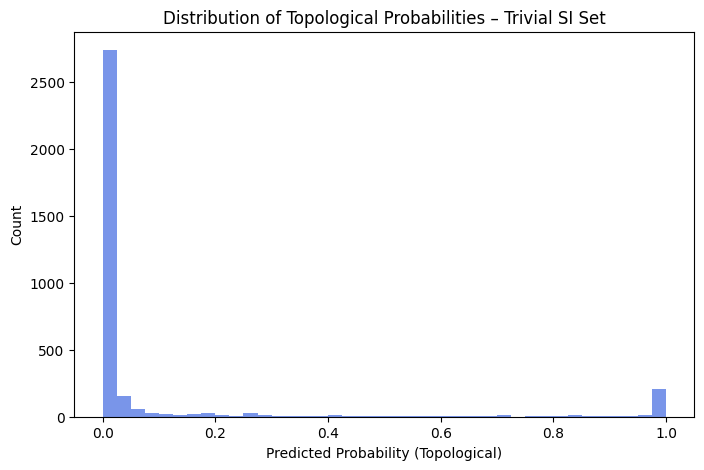

In [ ]:

#  Apply trained ElemNet final model to the discovery dataset (unlabeled materials)

import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

model = ElemNetBest().to(device)
model.load_state_dict(torch.load("elemnet_final_trainval.pt", map_location=device))
model.eval()

csv_new = "materiae_filtered_by_spacegroups_Trivial_Insulators_Trivial_SI_withCompositionVectors.csv"
df_new = pd.read_csv(csv_new, on_bad_lines="skip", engine="python")

if "composition_vector" not in df_new.columns:
    raise ValueError("❌ Column 'composition_vector' not found in CSV.")

df_new["composition_vector"] = df_new["composition_vector"].apply(eval)
X_new = np.vstack(df_new["composition_vector"].values).astype(np.float32)

with torch.no_grad():
    preds = model(torch.tensor(X_new).to(device)).cpu().numpy()

df_new["Predicted_Prob"] = preds
df_new["Predicted_Label"] = (preds > 0.5).astype(int)  # ← threshold adjustable!

output_csv = "predicted_topological_candidates_from_trivial_set.csv"
df_new.to_csv(output_csv, index=False)
print(f"✅ Predictions saved to: {output_csv}")
print(f"Total materials analyzed: {len(df_new)}")
print(f"Predicted topological: {(df_new['Predicted_Label'] == 1).sum()}")

top_preds = (
    df_new[df_new["Predicted_Label"] == 1]
    .sort_values("Predicted_Prob", ascending=False)
)
print("\n🔝 Top predicted topological candidates:")
cols_to_show = [c for c in ["formula", "spacegroup_number", "Predicted_Prob"] if c in df_new.columns]
print(top_preds[cols_to_show].head(15))

plt.figure(figsize=(8,5))
plt.hist(df_new["Predicted_Prob"], bins=40, color="royalblue", alpha=0.7)
plt.xlabel("Predicted Probability (Topological)")
plt.ylabel("Count")
plt.title("Distribution of Topological Probabilities – Trivial SI Set")
plt.show()


✅ Saved 51 predicted topological materials to 'topogivity_predicted_topological_candidates_from_best_model.csv'

🔝 Top predicted topological materials:
       formula  Predicted_Prob
13     BiPbPd2        1.000000
28        MgPt        1.000000
14        BiPd        1.000000
45        BiPd        1.000000
16      Bi3Pd8        0.999998
41      Sc9Te2        0.999997
37      Pd8Sb3        0.999996
36      Pd8Sb3        0.999996
51      Pd5Sb2        0.999995
50        OTi6        0.999994
35       Pd2Sb        0.999993
7       BLaPt2        0.999992
46    CaAl2Mo3        0.999991
1       Al2Mo5        0.999990
4         AsTa        0.999988
39   Re2Sc3Si3        0.999986
48    Ge6Y4Zn5        0.999982
33      Pb3Pd5        0.999974
38      ReSiTa        0.999958
2         AsNb        0.999957
30      NbReSi        0.999948
31        OTi3        0.999936
25        HgPd        0.999864
5       AuCaSn        0.999852
42        SiTi        0.999839
26        InSr        0.999816
20       Ge

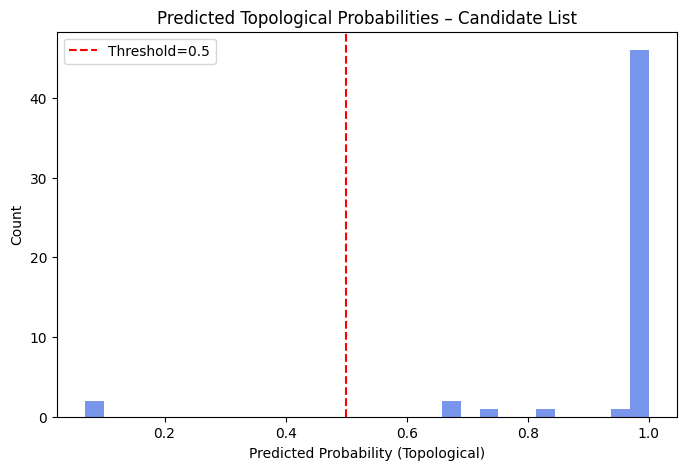

In [ ]:
# the final ElemNet model applied to the topogivity first paper (literature)-discovered materials

import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

model = ElemNetBest().to(device)
model.load_state_dict(torch.load("elemnet_final_trainval.pt", map_location=device))
model.eval()

csv_new = "topogivity_found_materials_withCompositionVectors.csv"
df_new = pd.read_csv(csv_new, on_bad_lines="skip", engine="python")

if "composition_vector" not in df_new.columns:
    raise ValueError("❌ 'composition_vector' column missing in CSV!")

df_new["composition_vector"] = df_new["composition_vector"].apply(
    lambda x: eval(x) if isinstance(x, str) else x
)

X_new = np.vstack(df_new["composition_vector"].values).astype(np.float32)

with torch.no_grad():
    preds = model(torch.tensor(X_new).to(device)).cpu().numpy()

df_new["Predicted_Prob"] = preds
threshold = 0.5  # you can raise to 0.6–0.7 for higher confidence
df_new["Predicted_Label"] = (preds > threshold).astype(int)

df_topo = df_new[df_new["Predicted_Label"] == 1].copy()
df_topo = df_topo.sort_values("Predicted_Prob", ascending=False)
=
output_csv = "topogivity_predicted_topological_candidates_from_best_model.csv"
df_topo.to_csv(output_csv, index=False)
print(f"✅ Saved {len(df_topo)} predicted topological materials to '{output_csv}'")
=
print("\n🔝 Top predicted topological materials:")
print(df_topo[["formula", "Predicted_Prob"]].head(52))

plt.figure(figsize=(8,5))
plt.hist(df_new["Predicted_Prob"], bins=30, color="royalblue", alpha=0.7)
plt.axvline(threshold, color="r", linestyle="--", label=f"Threshold={threshold}")
plt.xlabel("Predicted Probability (Topological)")
plt.ylabel("Count")
plt.title("Predicted Topological Probabilities – Candidate List")
plt.legend()
plt.show()


In [ ]:
# the final ElemNet model applied to the topogivity second paper (literature)-discovered materials

materials = [
    "As1Ta1", "Re2Sc1Si3", "B1La1Pt2", "P1Ta1", "Ge2Nb1", "Pd2Sb1", "Ge4Zr5",
    "As1Nb1", "Mo1Pt2Sn2", "Sc9Te2", "Ge1Pd1Y1", "Nb1P1", "Si4Zr5", "Si2W1",
    "Hf1Sn2", "Na1Pd3Si2", "Ca2Ge1Pd2", "Hf5Si4", "La5Si4", "Mg1Pt1", "Al2Y3",
    "Ca1Ge2Pd2", "Ba1Pd1Sn3", "O1Ti6", "O1Ti3", "Re1Si1Ta1", "Nb1Re1Si1",
    "ClAl2Mo3", "Bi3Pd8", "Ta2I1Te13", "Si1Ti1", "Bi1Pd1", "Bi1Pd1", "Bi2Pt1",
    "Ge1Pd5", "Bi1Pd1Pd2", "As1Pd5", "Pb3Pd5", "Re2Sc3Si3", "Pd8Sb3", "Hg1Pd1",
    "Pd5Sb2", "Re8Sc5Si12", "P3Sc7", "Pd1Sn3Sr1", "Al22Mo5", "Ag1Ge1La1",
    "Ba1Pt1Sn3", "Al5Mo1", "Au2Ga1", "As2Mo1", "Al1Ge1La1", "Au2Ga1",
    "As2Ta1", "Mo1P2", "Ge6Y4Zn5", "Ge3Pd1Sr1", "Pb2Pd3S2", "Au1Ca1Sn1",
    "As2Nb1", "Ba1Ge3Pt1", "Ge6La4Mg5", "Ge3Pt1Sr1", "Te2W1", "Ba1Pd1Si3",
    "In1Sr1", "Ag3Sb1", "Ca1Pt1Si3", "Ba3Sn2"
]

import torch
import numpy as np
from pymatgen.core import Composition




class ElemNetBest(nn.Module):
    def __init__(self):
        super().__init__()
        hidden_dims = [2048, 128, 512, 256, 128]
        dropout = 0.217
        act_fn = nn.LeakyReLU

        layers = []
        dims = [118] + hidden_dims
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i + 1]))
            layers.append(nn.BatchNorm1d(dims[i + 1]))
            layers.append(act_fn())
            layers.append(nn.Dropout(dropout))
        layers.append(nn.Linear(hidden_dims[-1], 1))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return torch.sigmoid(self.network(x)).squeeze(1)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ElemNetBest().to(device)
state = torch.load("elemnet_final_trainval.pt", map_location=device)
model.load_state_dict(state)
model.eval()



def composition_to_elemnet_vector(formula):
    comp = Composition(formula)
    vec = np.zeros(118, dtype=np.float32)
    for el, amt in comp.get_el_amt_dict().items():
        Z = Composition(el).elements[0].Z
        vec[Z-1] = amt / comp.num_atoms
    return torch.tensor(vec, dtype=torch.float32)



results = []

for formula in materials:
    x = composition_to_elemnet_vector(formula).unsqueeze(0).to(device)
    with torch.no_grad():
        pred = model(x)
    prob = float(pred.squeeze().cpu().numpy())
    results.append((formula, prob))

results_sorted = sorted(results, key=lambda x: x[1], reverse=True)

for formula, score in results_sorted:
    print(f"{formula:<12}  Topological Probability = {score:.3f}")


Ag3Sb1        Topological Probability = 1.000
Mg1Pt1        Topological Probability = 1.000
Bi1Pd1        Topological Probability = 1.000
Bi1Pd1        Topological Probability = 1.000
Ca1Ge2Pd2     Topological Probability = 1.000
Ge1Pd1Y1      Topological Probability = 1.000
Bi3Pd8        Topological Probability = 1.000
Bi1Pd1Pd2     Topological Probability = 1.000
Sc9Te2        Topological Probability = 1.000
Pd8Sb3        Topological Probability = 1.000
Pd5Sb2        Topological Probability = 1.000
O1Ti6         Topological Probability = 1.000
Pd2Sb1        Topological Probability = 1.000
B1La1Pt2      Topological Probability = 1.000
As1Ta1        Topological Probability = 1.000
Re2Sc3Si3     Topological Probability = 1.000
Ge6Y4Zn5      Topological Probability = 1.000
Ag1Ge1La1     Topological Probability = 1.000
Pb3Pd5        Topological Probability = 1.000
Re1Si1Ta1     Topological Probability = 1.000
As1Nb1        Topological Probability = 1.000
Nb1Re1Si1     Topological Probabil

In [ ]:
#print the final ElemNet model architecture used above

import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split


class ElemNetBest(nn.Module):
    def __init__(self):
        super().__init__()
        hidden_dims = [2048, 128, 512, 256, 128]
        dropout = 0.217
        act_fn = nn.LeakyReLU

        layers = []
        dims = [118] + hidden_dims
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i + 1]))
            layers.append(nn.BatchNorm1d(dims[i + 1]))
            layers.append(act_fn())
            layers.append(nn.Dropout(dropout))
        layers.append(nn.Linear(hidden_dims[-1], 1))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return torch.sigmoid(self.network(x)).squeeze(1)


In [8]:
print(model)

ElemNetBest(
  (network): Sequential(
    (0): Linear(in_features=118, out_features=2048, bias=True)
    (1): BatchNorm1d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
    (3): Dropout(p=0.217, inplace=False)
    (4): Linear(in_features=2048, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): LeakyReLU(negative_slope=0.01)
    (7): Dropout(p=0.217, inplace=False)
    (8): Linear(in_features=128, out_features=512, bias=True)
    (9): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.01)
    (11): Dropout(p=0.217, inplace=False)
    (12): Linear(in_features=512, out_features=256, bias=True)
    (13): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): LeakyReLU(negative_slope=0.01)
    (15): Dropout(p=0.217, inplace=False)
    (16): Linear(in_f

Topological materials: 8082


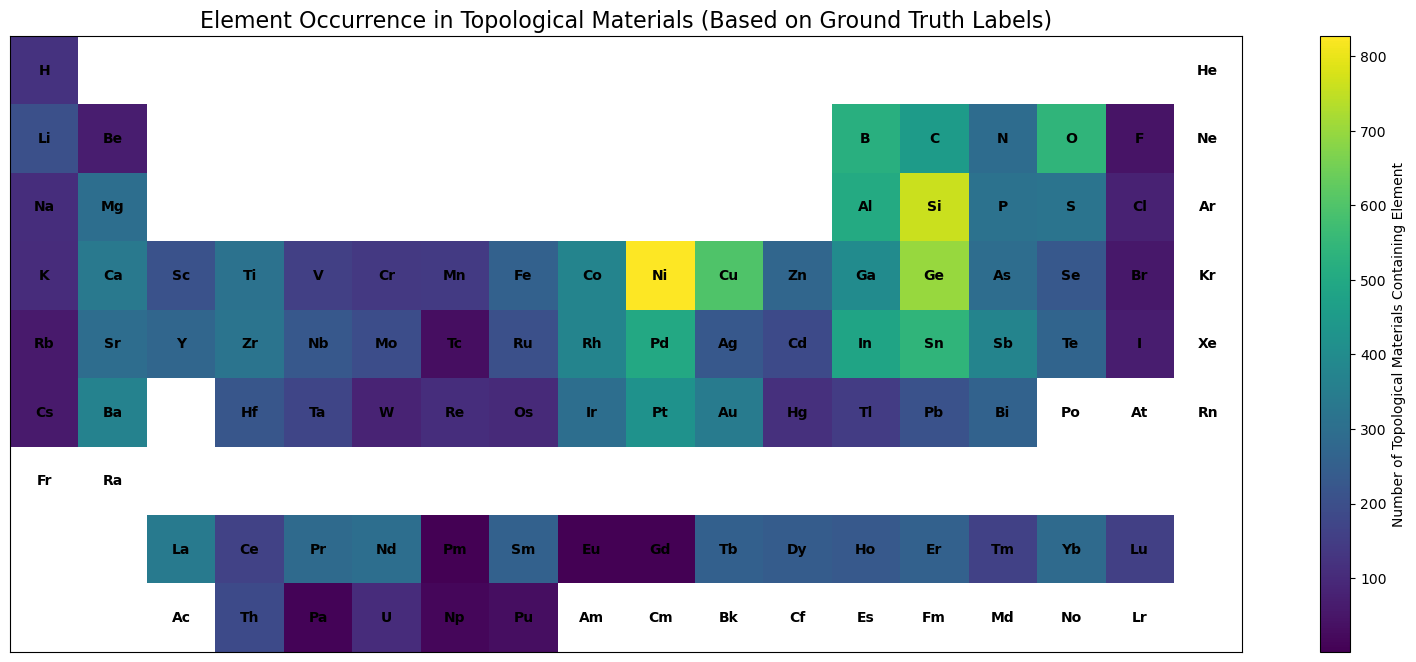

In [ ]:
# Element occurrence analysis in topological materials from the labelled dataset

import pandas as pd
from pymatgen.core import Composition
from collections import Counter

df = pd.read_csv("materiae_All_Labelled_withSOC_with_Composition_Vectors.csv")

# Keeping only topological materials
topo_df = df[df["is_topological"] == 1]
print("Topological materials:", len(topo_df))

element_counter = Counter()

for formula in topo_df["formula"]:
    comp = Composition(formula)
    for el in comp.elements:
        element_counter[el.symbol] += 1

occ = dict(element_counter)  # This is our score_dict


import numpy as np
import matplotlib.pyplot as plt

score_dict = occ  

ptable_coords = {
 'H':(0,0),'He':(17,0),
 'Li':(0,1),'Be':(1,1),'B':(12,1),'C':(13,1),'N':(14,1),'O':(15,1),'F':(16,1),'Ne':(17,1),
 'Na':(0,2),'Mg':(1,2),'Al':(12,2),'Si':(13,2),'P':(14,2),'S':(15,2),'Cl':(16,2),'Ar':(17,2),
 'K':(0,3),'Ca':(1,3),'Sc':(2,3),'Ti':(3,3),'V':(4,3),'Cr':(5,3),'Mn':(6,3),'Fe':(7,3),'Co':(8,3),'Ni':(9,3),'Cu':(10,3),'Zn':(11,3),
 'Ga':(12,3),'Ge':(13,3),'As':(14,3),'Se':(15,3),'Br':(16,3),'Kr':(17,3),
 'Rb':(0,4),'Sr':(1,4),'Y':(2,4),'Zr':(3,4),'Nb':(4,4),'Mo':(5,4),'Tc':(6,4),'Ru':(7,4),'Rh':(8,4),'Pd':(9,4),'Ag':(10,4),'Cd':(11,4),
 'In':(12,4),'Sn':(13,4),'Sb':(14,4),'Te':(15,4),'I':(16,4),'Xe':(17,4),
 'Cs':(0,5),'Ba':(1,5),'La':(2,5),'Hf':(3,5),'Ta':(4,5),'W':(5,5),'Re':(6,5),'Os':(7,5),'Ir':(8,5),'Pt':(9,5),'Au':(10,5),'Hg':(11,5),
 'Tl':(12,5),'Pb':(13,5),'Bi':(14,5),'Po':(15,5),'At':(16,5),'Rn':(17,5),
 'Fr':(0,6),'Ra':(1,6),'Ac':(2,6),
}

lanthanides = ["La","Ce","Pr","Nd","Pm","Sm","Eu","Gd","Tb","Dy","Ho","Er","Tm","Yb","Lu"]
actinides    = ["Ac","Th","Pa","U","Np","Pu","Am","Cm","Bk","Cf","Es","Fm","Md","No","Lr"]

for i,el in enumerate(lanthanides): ptable_coords[el] = (2+i, 7)
for i,el in enumerate(actinides):  ptable_coords[el] = (2+i, 8)

grid = np.full((9,18), np.nan, dtype=float)
symbols = np.full((9,18), "", dtype=object)

for el,(x,y) in ptable_coords.items():
    symbols[y,x] = el
    if el in score_dict:
        grid[y,x] = score_dict[el]

plt.figure(figsize=(20,8))
im = plt.imshow(grid, cmap="viridis")  # viridis is good for count data
plt.colorbar(label="Number of Topological Materials Containing Element")

for y in range(9):
    for x in range(18):
        if symbols[y,x] != "":
            plt.text(x, y, symbols[y,x], ha="center", va="center", fontsize=10, weight="bold")

plt.xticks([])
plt.yticks([])
plt.title("Element Occurrence in Topological Materials (Based on Ground Truth Labels)", fontsize=16)
plt.show()


In [ ]:
# Element contribution analysis using gradients from the final ElemNet model
import pandas as pd
import numpy as np
import torch

from pymatgen.core import Composition
from torch.utils.data import TensorDataset, DataLoader

df = pd.read_csv("materiae_All_Labelled_withSOC_with_Composition_Vectors.csv", on_bad_lines="skip", engine="python")
df["composition_vector"] = df["composition_vector"].apply(eval)

X = np.vstack(df["composition_vector"].values).astype(np.float32)
y = df["is_topological"].astype(np.float32).values

print(f"✅ Dataset loaded: {X.shape[0]} samples, {X.shape[1]} features")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = ElemNetBest().to(device)
model.load_state_dict(torch.load("elemnet_final_trainval.pt", map_location=device))
model.eval()

import torch

def element_contribution(formula_vector):
    """
    formula_vector: 118-d composition vector, torch tensor shape (1,118)
    returns: contribution per element → tensor (118,)
    """
    formula_vector = formula_vector.to(device).requires_grad_(True)

    output = model(formula_vector)  # predicted prob
    output.backward()  # gradient wrt input

    grad = formula_vector.grad.detach()         
    contribution = (grad * formula_vector).cpu() 

    return contribution.squeeze()  # shape → (118,)


import numpy as np

contrib_sum = np.zeros(118)
count = 0

for vec in X:
    vec_t = torch.tensor(vec).unsqueeze(0).float()
    contrib = element_contribution(vec_t)   # shape (118,)

    contrib_sum += contrib.detach().numpy()  
    count += 1

global_contrib = contrib_sum / count



✅ Dataset loaded: 22245 samples, 118 features
Using device: cpu


In [38]:
from pymatgen.core.periodic_table import Element
element_names = [Element.from_Z(i).symbol for i in range(1, 119)]
global_contrib_dict = {el: global_contrib[i-1] for i, el in enumerate(element_names, start=1)}

print("✅ Contribution scores computed.")


✅ Contribution scores computed.


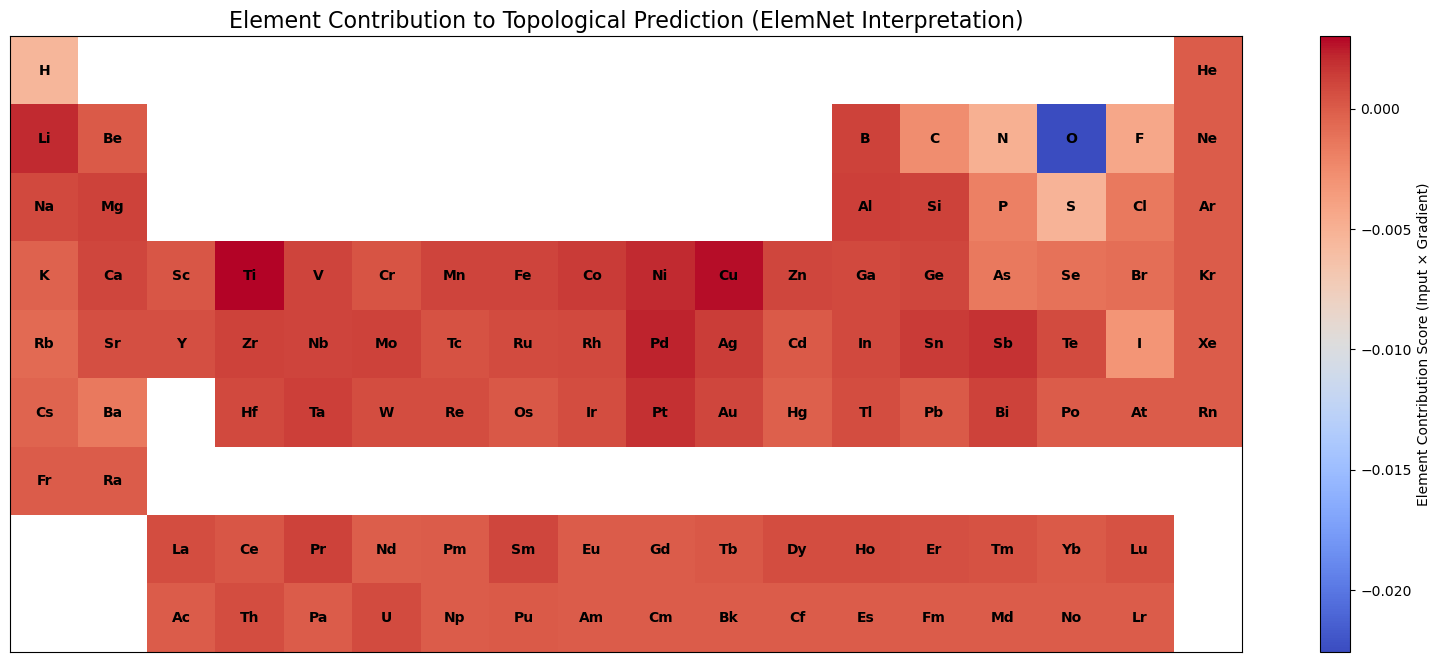

In [39]:
import numpy as np
import matplotlib.pyplot as plt

score_dict = global_contrib_dict  # rename for clarity

ptable_coords = {
 'H':(0,0),'He':(17,0),
 'Li':(0,1),'Be':(1,1),'B':(12,1),'C':(13,1),'N':(14,1),'O':(15,1),'F':(16,1),'Ne':(17,1),
 'Na':(0,2),'Mg':(1,2),'Al':(12,2),'Si':(13,2),'P':(14,2),'S':(15,2),'Cl':(16,2),'Ar':(17,2),
 'K':(0,3),'Ca':(1,3),'Sc':(2,3),'Ti':(3,3),'V':(4,3),'Cr':(5,3),'Mn':(6,3),'Fe':(7,3),'Co':(8,3),'Ni':(9,3),'Cu':(10,3),'Zn':(11,3),
 'Ga':(12,3),'Ge':(13,3),'As':(14,3),'Se':(15,3),'Br':(16,3),'Kr':(17,3),
 'Rb':(0,4),'Sr':(1,4),'Y':(2,4),'Zr':(3,4),'Nb':(4,4),'Mo':(5,4),'Tc':(6,4),'Ru':(7,4),'Rh':(8,4),'Pd':(9,4),'Ag':(10,4),'Cd':(11,4),
 'In':(12,4),'Sn':(13,4),'Sb':(14,4),'Te':(15,4),'I':(16,4),'Xe':(17,4),
 'Cs':(0,5),'Ba':(1,5),'La':(2,5),'Hf':(3,5),'Ta':(4,5),'W':(5,5),'Re':(6,5),'Os':(7,5),'Ir':(8,5),'Pt':(9,5),'Au':(10,5),'Hg':(11,5),
 'Tl':(12,5),'Pb':(13,5),'Bi':(14,5),'Po':(15,5),'At':(16,5),'Rn':(17,5),
 'Fr':(0,6),'Ra':(1,6),'Ac':(2,6),
}

lanthanides = ["La","Ce","Pr","Nd","Pm","Sm","Eu","Gd","Tb","Dy","Ho","Er","Tm","Yb","Lu"]
actinides    = ["Ac","Th","Pa","U","Np","Pu","Am","Cm","Bk","Cf","Es","Fm","Md","No","Lr"]

for i, el in enumerate(lanthanides): ptable_coords[el] = (2+i, 7)
for i, el in enumerate(actinides):  ptable_coords[el] = (2+i, 8)

grid = np.full((9,18), np.nan, dtype=float)
symbols = np.full((9,18), "", dtype=object)

for el, (x, y) in ptable_coords.items():
    symbols[y, x] = el
    if el in score_dict:
        grid[y, x] = score_dict[el]


plt.figure(figsize=(20,8))
im = plt.imshow(grid, cmap="coolwarm", vmin=np.nanmin(grid), vmax=np.nanmax(grid))
plt.colorbar(label="Element Contribution Score (Input × Gradient)")

for y in range(9):
    for x in range(18):
        if symbols[y, x] != "":
            plt.text(x, y, symbols[y, x], ha="center", va="center", fontsize=10, weight="bold")

plt.xticks([])
plt.yticks([])
plt.title("Element Contribution to Topological Prediction (ElemNet Interpretation)", fontsize=16)
plt.show()
